# Enflasyonist Ortamlarda Talep Esnekliğine Dayalı Dinamik Fiyatlama ve Kâr Optimizasyonu

Bu projede Online Retail ve UK CPI veri setleri kullanılarak talep tahmini, fiyat optimizasyonu ve karar destek sistemi geliştirilmiştir.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [4]:
retail = pd.read_csv("data/online_retail.csv")
cpi = pd.read_csv("data/UK_CPI.csv")

In [5]:
print("Retail Boyut:", retail.shape)
print("CPI Boyut:", cpi.shape)

Retail Boyut: (541909, 8)
CPI Boyut: (843, 2)


In [6]:
print(retail.columns)
print(cpi.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
Index(['observation_date', 'GBRCPIALLMINMEI'], dtype='object')


In [7]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
cpi.head()

,observation_date,GBRCPIALLMINMEI
0,1955-01-01,4.859513
1,1955-02-01,4.859513
2,1955-03-01,4.859513
3,1955-04-01,4.885972
4,1955-05-01,4.877152


In [9]:
retail.isnull().sum()
cpi.isnull().sum()

observation_date    0
GBRCPIALLMINMEI     0
dtype: int64

In [10]:
retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
retail["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [12]:
(retail["Quantity"] <= 0).sum()

np.int64(10624)

In [13]:
(retail["UnitPrice"] <= 0).sum()

np.int64(2517)

In [14]:
retail_clean = retail.copy()

retail_clean = retail_clean[
    retail_clean["Country"] == "United Kingdom"
]

retail_clean = retail_clean[
    retail_clean["Quantity"] > 0
]

retail_clean = retail_clean[
    retail_clean["UnitPrice"] > 0
]

In [15]:
print("Orijinal Veri Boyutu:", retail.shape)
print("Temizlenmiş Veri Boyutu:", retail_clean.shape)

Orijinal Veri Boyutu: (541909, 8)
Temizlenmiş Veri Boyutu: (485123, 8)


In [16]:
print(
    "Negatif Quantity:",
    (retail_clean["Quantity"] <= 0).sum()
)

print(
    "Negatif Fiyat:",
    (retail_clean["UnitPrice"] <= 0).sum()
)

print(
    "Farklı Ülkeler:",
    retail_clean["Country"].nunique()
)

Negatif Quantity: 0
Negatif Fiyat: 0
Farklı Ülkeler: 1


In [17]:
retail_clean["InvoiceDate"] = pd.to_datetime(
    retail_clean["InvoiceDate"]
)

In [18]:
retail_clean["Year"] = retail_clean["InvoiceDate"].dt.year

retail_clean["Month"] = retail_clean["InvoiceDate"].dt.month

retail_clean["YearMonth"] = retail_clean["InvoiceDate"].dt.to_period("M")

In [19]:
cpi["observation_date"] = pd.to_datetime(
    cpi["observation_date"]
)

In [20]:
cpi["YearMonth"] = cpi["observation_date"].dt.to_period("M")

In [21]:
cpi = cpi.rename(
    columns={
        "GBRCPIALLMINMEI": "CPI"
    }
)

In [22]:
retail_clean[[
    "InvoiceDate",
    "Year",
    "Month",
    "YearMonth"
]].head()

,InvoiceDate,Year,Month,YearMonth
0,2010-12-01 08:26:00,2010,12,2010-12
1,2010-12-01 08:26:00,2010,12,2010-12
2,2010-12-01 08:26:00,2010,12,2010-12
3,2010-12-01 08:26:00,2010,12,2010-12
4,2010-12-01 08:26:00,2010,12,2010-12


In [23]:
cpi.head()

,observation_date,CPI,YearMonth
0,1955-01-01,4.859513,1955-01
1,1955-02-01,4.859513,1955-02
2,1955-03-01,4.859513,1955-03
3,1955-04-01,4.885972,1955-04
4,1955-05-01,4.877152,1955-05


In [24]:
retail_cpi = retail_clean.merge(
    cpi[["YearMonth", "CPI"]],
    on="YearMonth",
    how="left"
)

In [25]:
retail_cpi.shape

(485123, 12)

In [26]:
retail_cpi.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,YearMonth,CPI
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,2010-12,91.7
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,2010-12,91.7
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,2010-12,91.7
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,2010-12,91.7
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,2010-12,91.7


In [27]:
retail_cpi["CPI"].isnull().sum()

np.int64(0)

In [28]:
retail_cpi["Sales"] = (
    retail_cpi["Quantity"]
    * retail_cpi["UnitPrice"]
)

In [29]:
retail_cpi[[
    "Quantity",
    "UnitPrice",
    "Sales",
    "CPI"
]].head()

,Quantity,UnitPrice,Sales,CPI
0,6,2.55,15.30,91.7
1,6,3.39,20.34,91.7
2,8,2.75,22.00,91.7
3,6,3.39,20.34,91.7
4,6,3.39,20.34,91.7


In [30]:
retail_cpi["RealPrice"] = (
    retail_cpi["UnitPrice"]
    / retail_cpi["CPI"]
)

In [31]:
retail_cpi[[
    "UnitPrice",
    "CPI",
    "RealPrice"
]].head()

,UnitPrice,CPI,RealPrice
0,2.55,91.7,0.027808
1,3.39,91.7,0.036968
2,2.75,91.7,0.029989
3,3.39,91.7,0.036968
4,3.39,91.7,0.036968


In [32]:
print(
    retail_clean["InvoiceDate"].min()
)

print(
    retail_clean["InvoiceDate"].max()
)

2010-12-01 08:26:00
2011-12-09 12:49:00


In [33]:
cpi_filtered = cpi[
    (cpi["observation_date"] >= "2010-12-01")
    &
    (cpi["observation_date"] <= "2011-12-31")
].copy()

In [34]:
cpi_filtered.shape

(13, 3)

In [35]:
retail_cpi = retail_clean.merge(
    cpi_filtered[["YearMonth", "CPI"]],
    on="YearMonth",
    how="left"
)

In [36]:
retail_cpi["CPI"].isnull().sum()

np.int64(0)

In [37]:
retail_cpi.shape

(485123, 12)

In [38]:
retail_cpi.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Year', 'Month', 'YearMonth',
       'CPI'],
      dtype='object')

In [39]:
retail_cpi["Sales"] = (
    retail_cpi["Quantity"]
    * retail_cpi["UnitPrice"]
)

retail_cpi["RealPrice"] = (
    retail_cpi["UnitPrice"]
    / retail_cpi["CPI"]
)

In [40]:
monthly_product = (
    retail_cpi
    .groupby(
        ["StockCode", "YearMonth"]
    )
    .agg({
        "Quantity": "sum",
        "UnitPrice": "mean",
        "Sales": "sum",
        "CPI": "mean",
        "RealPrice": "mean"
    })
    .reset_index()
)

In [41]:
monthly_product.shape


(33746, 7)

In [42]:
monthly_product.head()

,StockCode,YearMonth,Quantity,UnitPrice,Sales,CPI,RealPrice
0,10002,2010-12,143,1.255000,142.61,91.7,0.013686
1,10002,2011-01,147,1.019286,127.32,91.8,0.011103
2,10002,2011-02,51,1.110000,44.91,92.3,0.012026
3,10002,2011-03,28,1.142500,27.70,92.6,0.012338
4,10002,2011-04,69,0.850000,58.65,93.3,0.009110


In [43]:
monthly_product = monthly_product.sort_values(
    ["StockCode", "YearMonth"]
)

monthly_product["PriceChangeRate"] = (
    monthly_product
    .groupby("StockCode")["UnitPrice"]
    .pct_change()
)

In [44]:
monthly_product["RollingDemand3M"] = (
    monthly_product
    .groupby("StockCode")["Quantity"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

In [45]:
monthly_product["PreviousMonthDemand"] = (
    monthly_product
    .groupby("StockCode")["Quantity"]
    .shift(1)
)

In [46]:
monthly_product.head(15)

,StockCode,YearMonth,Quantity,UnitPrice,Sales,CPI,RealPrice,PriceChangeRate,RollingDemand3M,PreviousMonthDemand
0,10002,2010-12,143,1.255000,142.61,91.7,0.013686,NaN,143.000000,NaN
1,10002,2011-01,147,1.019286,127.32,91.8,0.011103,-1.878201e-01,145.000000,143.0
2,10002,2011-02,51,1.110000,44.91,92.3,0.012026,8.899790e-02,113.666667,147.0
3,10002,2011-03,28,1.142500,27.70,92.6,0.012338,2.927928e-02,75.333333,51.0
4,10002,2011-04,69,0.850000,58.65,93.3,0.009110,-2.560175e-01,49.333333,28.0
5,10080,2011-02,2,0.850000,1.70,92.3,0.009209,NaN,2.000000,NaN
6,10080,2011-06,60,0.390000,23.40,93.5,0.004171,-5.411765e-01,31.000000,2.0
7,10080,2011-07,24,0.390000,9.36,93.5,0.004171,0.000000e+00,28.666667,60.0
8,10080,2011-08,60,0.390000,23.40,93.9,0.004153,0.000000e+00,48.000000,24.0
9,10080,2011-09,60,0.390000,23.40,94.5,0.004127,0.000000e+00,48.000000,60.0


In [47]:
monthly_product.isnull().sum()

StockCode                 0
YearMonth                 0
Quantity                  0
UnitPrice                 0
Sales                     0
CPI                       0
RealPrice                 0
PriceChangeRate        3916
RollingDemand3M           0
PreviousMonthDemand    3916
dtype: int64

In [48]:
monthly_product = monthly_product.dropna(
    subset=[
        "PriceChangeRate",
        "PreviousMonthDemand"
    ]
)

In [49]:
monthly_product.shape

(29830, 10)

In [50]:
monthly_product.head()

,StockCode,YearMonth,Quantity,UnitPrice,Sales,CPI,RealPrice,PriceChangeRate,RollingDemand3M,PreviousMonthDemand
1,10002,2011-01,147,1.019286,127.32,91.8,0.011103,-0.187820,145.000000,143.0
2,10002,2011-02,51,1.110000,44.91,92.3,0.012026,0.088998,113.666667,147.0
3,10002,2011-03,28,1.142500,27.70,92.6,0.012338,0.029279,75.333333,51.0
4,10002,2011-04,69,0.850000,58.65,93.3,0.009110,-0.256018,49.333333,28.0
6,10080,2011-06,60,0.390000,23.40,93.5,0.004171,-0.541176,31.000000,2.0


In [51]:
monthly_product["DemandChangeRate"] = (
    monthly_product
    .groupby("StockCode")["Quantity"]
    .pct_change()
)

In [52]:
monthly_product["Elasticity"] = (
    monthly_product["DemandChangeRate"]
    /
    monthly_product["PriceChangeRate"]
)

In [53]:
monthly_product = monthly_product.replace(
    [np.inf, -np.inf],
    np.nan
)

In [54]:
monthly_product = monthly_product.dropna(
    subset=[
        "Elasticity"
    ]
)

In [55]:
monthly_product.shape

(21164, 12)

In [56]:
monthly_product[[
    "StockCode",
    "Quantity",
    "UnitPrice",
    "DemandChangeRate",
    "PriceChangeRate",
    "Elasticity"
]].head(20)

,StockCode,Quantity,UnitPrice,DemandChangeRate,PriceChangeRate,Elasticity
2,10002,51,1.110000,-0.653061,8.899790e-02,-7.337940e+00
3,10002,28,1.142500,-0.450980,2.927928e-02,-1.540271e+01
4,10002,69,0.850000,1.464286,-2.560175e-01,-5.719475e+00
10,10080,6,0.390000,-0.900000,-1.110223e-16,8.106479e+15
14,10120,29,0.210000,-0.033333,2.220446e-16,-1.501200e+14
15,10120,3,0.210000,-0.896552,-1.110223e-16,8.075420e+15
34,10125,74,0.991818,-0.516340,3.439271e-01,-1.501306e+00
35,10125,62,0.850000,-0.162162,-1.429881e-01,1.134096e+00
37,10125,15,1.110000,1.142857,3.058824e-01,3.736264e+00
38,10125,77,0.928000,4.133333,-1.639640e-01,-2.520879e+01


In [57]:
monthly_product["Elasticity"].describe()

count    2.116400e+04
mean    -2.318151e+13
std      2.560338e+15
min     -1.891512e+17
25%     -8.529158e+00
50%     -1.388687e+00
75%      3.282799e+00
max      7.430939e+16
Name: Elasticity, dtype: float64

In [58]:
monthly_product["Elasticity"].quantile(
    [0.01, 0.05, 0.95, 0.99]
)

0.01    -2199.945000
0.05      -89.648298
0.95       54.830015
0.99    74339.338266
Name: Elasticity, dtype: float64

In [59]:
monthly_product = monthly_product[
    monthly_product["PriceChangeRate"].abs() > 0.01
]

In [60]:
monthly_product["Elasticity"] = (
    monthly_product["DemandChangeRate"]
    /
    monthly_product["PriceChangeRate"]
)

In [61]:
monthly_product = monthly_product.replace(
    [np.inf, -np.inf],
    np.nan
)

monthly_product = monthly_product.dropna(
    subset=["Elasticity"]
)

In [62]:
q01 = monthly_product["Elasticity"].quantile(0.01)
q99 = monthly_product["Elasticity"].quantile(0.99)

monthly_product = monthly_product[
    (monthly_product["Elasticity"] >= q01)
    &
    (monthly_product["Elasticity"] <= q99)
]

In [63]:
monthly_product["Elasticity"].describe()

count    19081.000000
mean        -4.688282
std         24.617414
min       -201.348000
25%         -7.221130
50%         -1.398105
75%          2.567045
max         95.055900
Name: Elasticity, dtype: float64

In [64]:
monthly_product.shape

(19081, 12)

In [65]:
features = [
    "UnitPrice",
    "CPI",
    "RealPrice",
    "PriceChangeRate",
    "RollingDemand3M",
    "PreviousMonthDemand",
    "Elasticity"
]

target = "Quantity"

In [66]:
X = monthly_product[features]

y = monthly_product[target]

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [68]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(15264, 7)
(3817, 7)
(15264,)
(3817,)


In [69]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
rf_predictions = rf_model.predict(X_test)

In [71]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5

r2 = r2_score(
    y_test,
    rf_predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 36.8051231333508
RMSE: 197.44712729701223
R²: 0.7147302981013821


In [72]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
4,RollingDemand3M,0.799696
5,PreviousMonthDemand,0.059261
6,Elasticity,0.052941
3,PriceChangeRate,0.038993
1,CPI,0.033626
2,RealPrice,0.008194
0,UnitPrice,0.007289


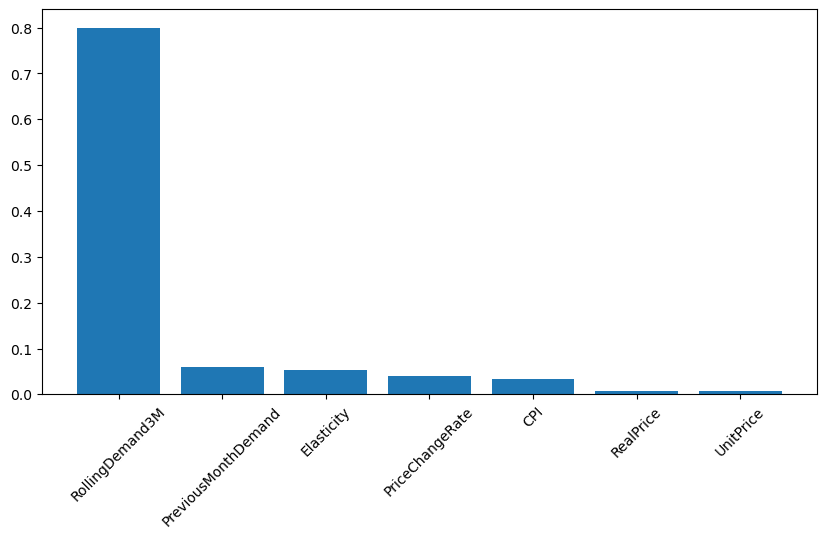

In [73]:
plt.figure(figsize=(10,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.show()

In [74]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 36.8051231333508
RMSE: 197.44712729701223
R²: 0.7147302981013821


In [75]:
!pip install xgboost

In [76]:
from xgboost import XGBRegressor

In [77]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

In [78]:
xgb_model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [79]:
xgb_predictions = xgb_model.predict(
    X_test
)

In [80]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = mean_squared_error(
    y_test,
    xgb_predictions
) ** 0.5

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

MAE: 35.734886169433594
RMSE: 185.53680564782826
R²: 0.7481081485748291


In [81]:
xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
4,RollingDemand3M,0.743779
1,CPI,0.093344
6,Elasticity,0.057260
3,PriceChangeRate,0.037975
5,PreviousMonthDemand,0.033087
2,RealPrice,0.025758
0,UnitPrice,0.008796


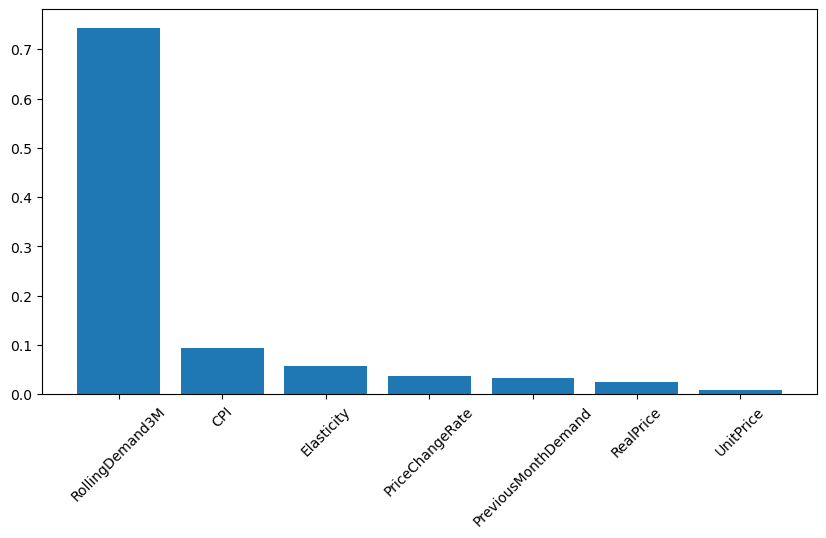

In [82]:
plt.figure(figsize=(10,5))

plt.bar(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xticks(rotation=45)

plt.show()

In [83]:
!pip install shap

In [84]:
import shap

In [85]:
explainer = shap.TreeExplainer(
    xgb_model
)

In [86]:
shap_values = explainer.shap_values(
    X_test
)

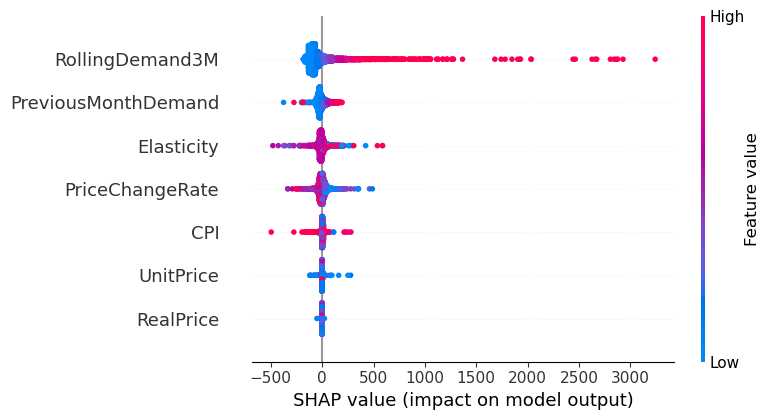

In [87]:
shap.summary_plot(
    shap_values,
    X_test
)

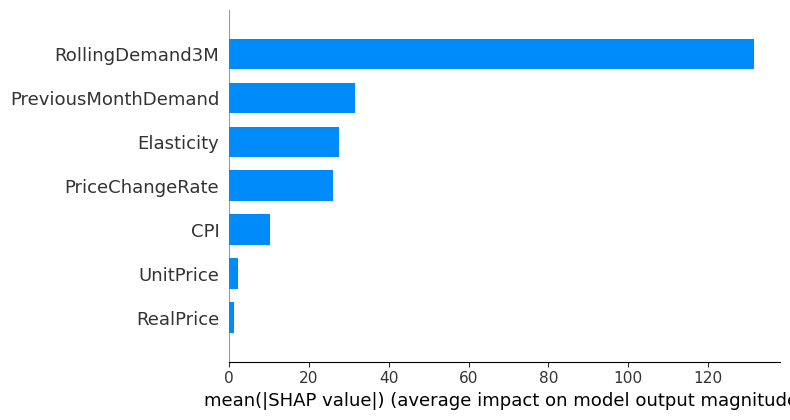

In [88]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [89]:
simulation_df = monthly_product.copy()


In [90]:
price_scenarios = [
    -0.20,
    -0.10,
     0.00,
     0.10,
     0.20
]

In [91]:
results = []

In [92]:
for scenario in price_scenarios:

    temp = simulation_df.copy()

    temp["UnitPrice"] = (
        temp["UnitPrice"]
        * (1 + scenario)
    )

    temp["RealPrice"] = (
        temp["UnitPrice"]
        / temp["CPI"]
    )

    predicted_demand = xgb_model.predict(
        temp[features]
    )

    temp["PredictedDemand"] = predicted_demand

    temp["Revenue"] = (
        temp["UnitPrice"]
        * temp["PredictedDemand"]
    )

    temp["Cost"] = (
        temp["UnitPrice"]
        * 0.70
        * temp["PredictedDemand"]
    )

    temp["Profit"] = (
        temp["Revenue"]
        - temp["Cost"]
    )

    results.append({
        "Scenario": scenario,
        "TotalProfit": temp["Profit"].sum()
    })

In [93]:
profit_results = pd.DataFrame(
    results
)

profit_results

,Scenario,TotalProfit
0,-0.2,1.681061e+06
1,-0.1,1.888848e+06
2,0.0,2.093641e+06
3,0.1,2.297515e+06
4,0.2,2.504188e+06


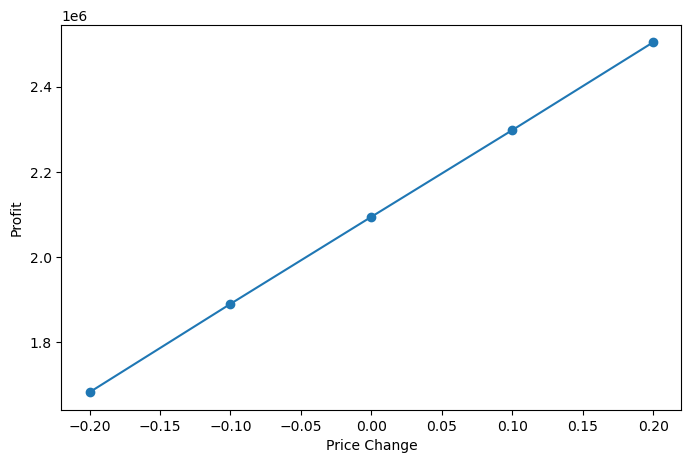

In [94]:
plt.figure(figsize=(8,5))

plt.plot(
    profit_results["Scenario"],
    profit_results["TotalProfit"],
    marker="o"
)

plt.xlabel("Price Change")

plt.ylabel("Profit")

plt.show()

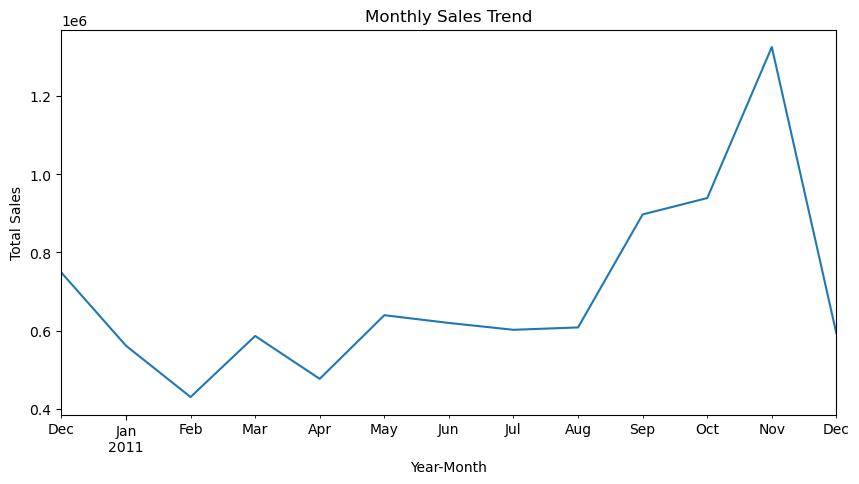

In [95]:
monthly_sales = (
    retail_cpi
    .groupby("YearMonth")["Sales"]
    .sum()
)

plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")

plt.show()

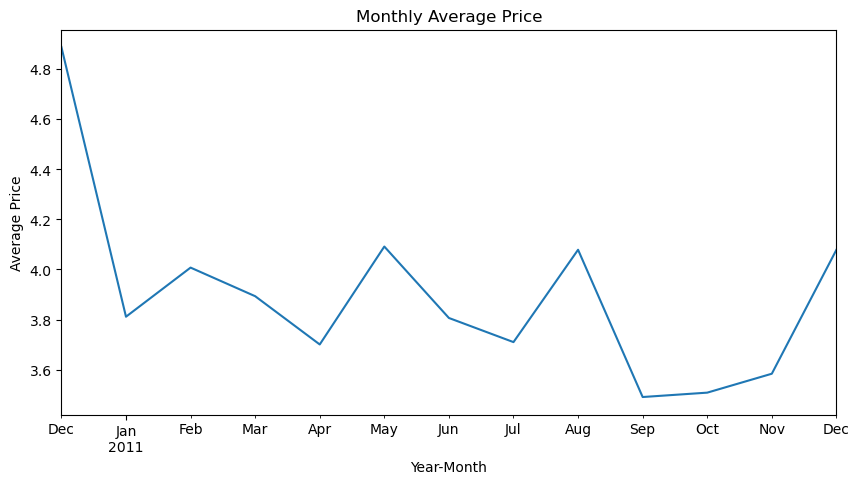

In [96]:
monthly_price = (
    retail_cpi
    .groupby("YearMonth")["UnitPrice"]
    .mean()
)

plt.figure(figsize=(10,5))

monthly_price.plot()

plt.title("Monthly Average Price")
plt.xlabel("Year-Month")
plt.ylabel("Average Price")

plt.show()

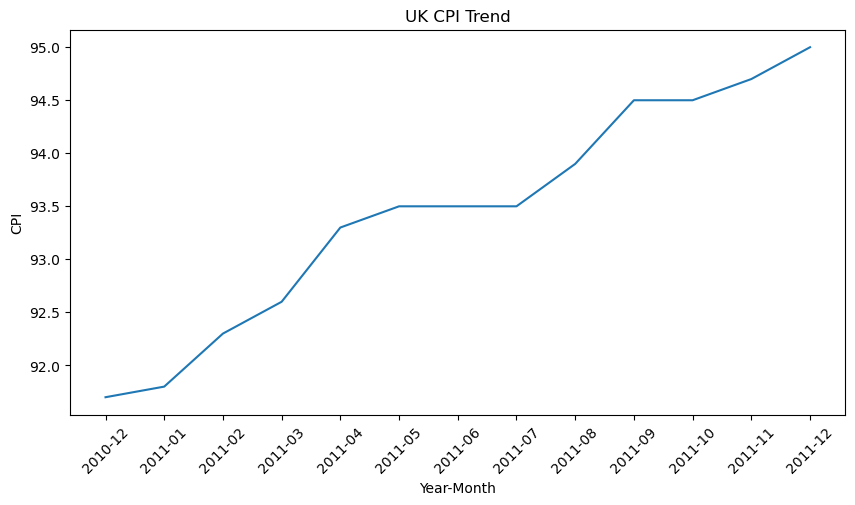

In [97]:
plt.figure(figsize=(10,5))

plt.plot(
    cpi_filtered["YearMonth"].astype(str),
    cpi_filtered["CPI"]
)

plt.title("UK CPI Trend")
plt.xlabel("Year-Month")
plt.ylabel("CPI")

plt.xticks(rotation=45)

plt.show()

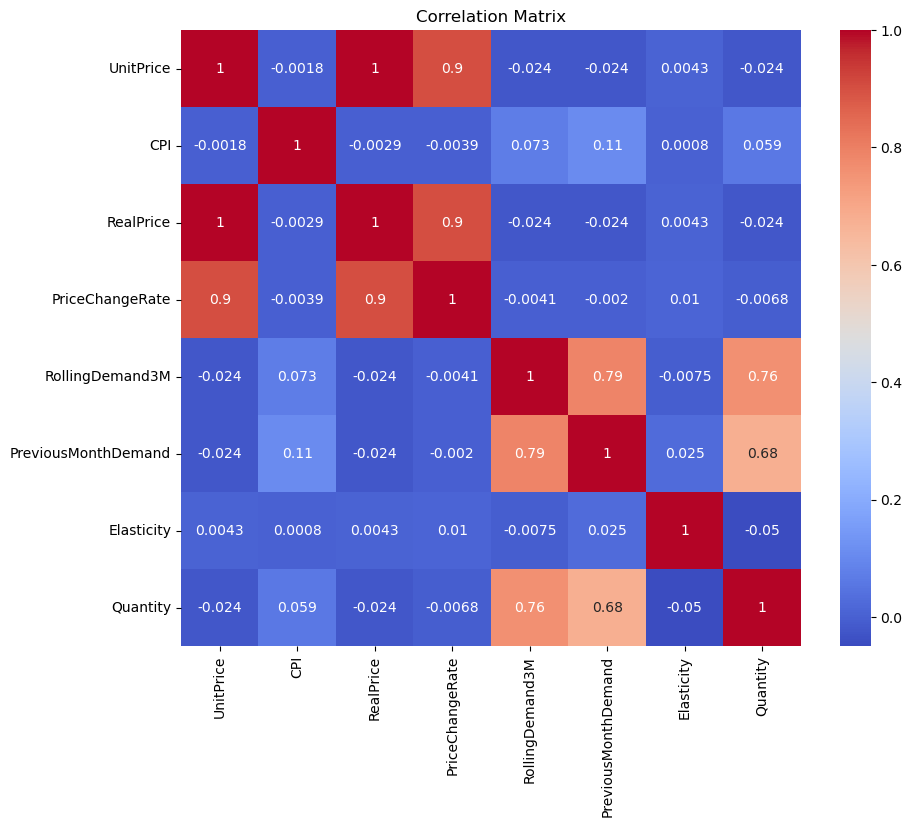

In [98]:
plt.figure(figsize=(10,8))

sns.heatmap(
    monthly_product[
        features + ["Quantity"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [99]:
monthly_product["ElasticityGroup"] = pd.cut(
    monthly_product["Elasticity"],
    bins=[
        -999,
        -2,
        -1,
        1,
        999
    ],
    labels=[
        "Highly Elastic",
        "Elastic",
        "Unit Elastic",
        "Inelastic"
    ]
)

In [100]:
monthly_product["ElasticityGroup"].value_counts()

ElasticityGroup
Highly Elastic    8671
Inelastic         6138
Unit Elastic      2782
Elastic           1490
Name: count, dtype: int64

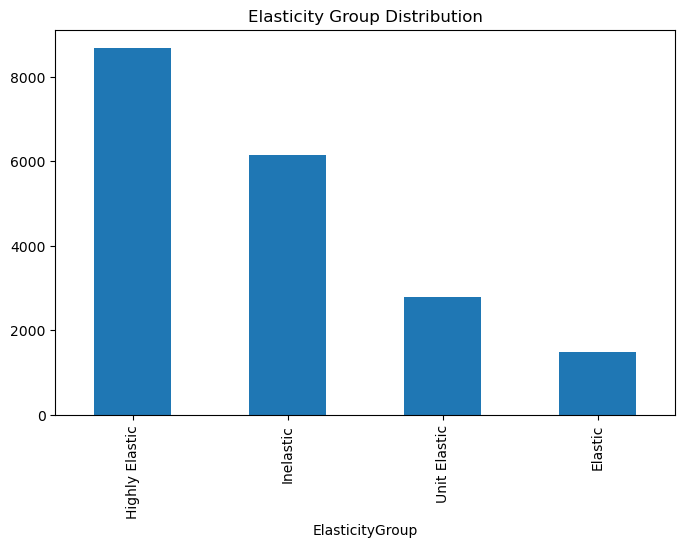

In [101]:
monthly_product[
    "ElasticityGroup"
].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Elasticity Group Distribution"
)

plt.show()

In [102]:
monthly_product.groupby(
    "ElasticityGroup",
    observed=False
)["Quantity"].mean()

ElasticityGroup
Highly Elastic    173.854803
Elastic           100.570470
Unit Elastic      106.976636
Inelastic         171.595960
Name: Quantity, dtype: float64

In [103]:
monthly_product.groupby(
    "ElasticityGroup",
    observed=False
)["UnitPrice"].mean()

ElasticityGroup
Highly Elastic    3.704428
Elastic           4.655061
Unit Elastic      6.335185
Inelastic         3.743033
Name: UnitPrice, dtype: float64

In [104]:
monthly_product.groupby(
    "ElasticityGroup",
    observed=False
)["Elasticity"].mean()

ElasticityGroup
Highly Elastic   -18.647920
Elastic           -1.485893
Unit Elastic      -0.125288
Inelastic         12.186630
Name: Elasticity, dtype: float64

In [105]:
monthly_product["ElasticityGroup"].value_counts()

ElasticityGroup
Highly Elastic    8671
Inelastic         6138
Unit Elastic      2782
Elastic           1490
Name: count, dtype: int64

In [106]:
best_scenario = profit_results.loc[
    profit_results["TotalProfit"].idxmax()
]

best_scenario

Scenario       2.000000e-01
TotalProfit    2.504188e+06
Name: 4, dtype: float64

In [107]:
profit_results["Recommendation"] = [
    "Strong Discount",
    "Discount",
    "Current Price",
    "Price Increase",
    "Strong Price Increase"
]

profit_results

,Scenario,TotalProfit,Recommendation
0,-0.2,1.681061e+06,Strong Discount
1,-0.1,1.888848e+06,Discount
2,0.0,2.093641e+06,Current Price
3,0.1,2.297515e+06,Price Increase
4,0.2,2.504188e+06,Strong Price Increase


In [108]:
profit_results.sort_values(
    by="TotalProfit",
    ascending=False
)

,Scenario,TotalProfit,Recommendation
4,0.2,2.504188e+06,Strong Price Increase
3,0.1,2.297515e+06,Price Increase
2,0.0,2.093641e+06,Current Price
1,-0.1,1.888848e+06,Discount
0,-0.2,1.681061e+06,Strong Discount


In [109]:
print(
    "Best Price Change:",
    best_scenario["Scenario"]
)

print(
    "Expected Profit:",
    round(
        best_scenario["TotalProfit"],
        2
    )
)

Best Price Change: 0.2
Expected Profit: 2504188.1


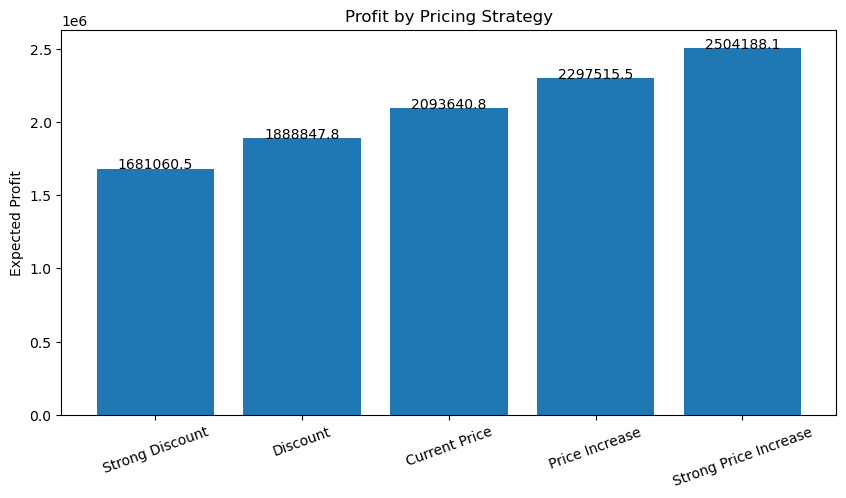

In [110]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    profit_results["Recommendation"],
    profit_results["TotalProfit"]
)

plt.title(
    "Profit by Pricing Strategy"
)

plt.ylabel(
    "Expected Profit"
)

plt.xticks(rotation=20)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),1),
        ha="center"
    )

plt.show()

In [111]:
simulation_df.columns

Index(['StockCode', 'YearMonth', 'Quantity', 'UnitPrice', 'Sales', 'CPI',
       'RealPrice', 'PriceChangeRate', 'RollingDemand3M',
       'PreviousMonthDemand', 'DemandChangeRate', 'Elasticity'],
      dtype='object')

In [113]:
simulation_df = monthly_product.copy()

In [114]:
simulation_df["ElasticityGroup"].value_counts()

ElasticityGroup
Highly Elastic    8671
Inelastic         6138
Unit Elastic      2782
Elastic           1490
Name: count, dtype: int64

In [115]:
group_profit = (
    simulation_df
    .groupby("ElasticityGroup", observed=False)
    .agg({
        "Sales":"sum"
    })
)

group_profit

,Sales
ElasticityGroup,
Highly Elastic,2813015.931
Elastic,283610.920
Unit Elastic,676007.590
Inelastic,2045317.090


In [116]:
group_results = []

In [117]:
simulation_df["ElasticityGroup"].unique()

['Highly Elastic', 'Elastic', 'Inelastic', 'Unit Elastic']
Categories (4, object): ['Highly Elastic' < 'Elastic' < 'Unit Elastic' < 'Inelastic']

In [118]:
for group in simulation_df["ElasticityGroup"].dropna().unique():

    group_data = simulation_df[
        simulation_df["ElasticityGroup"] == group
    ].copy()

    for scenario in [-0.20, -0.10, 0.00, 0.10, 0.20]:

        temp = group_data.copy()

        temp["UnitPrice"] = (
            temp["UnitPrice"]
            * (1 + scenario)
        )

        temp["RealPrice"] = (
            temp["UnitPrice"]
            / temp["CPI"]
        )

        predicted_demand = xgb_model.predict(
            temp[features]
        )

        temp["Revenue"] = (
            temp["UnitPrice"]
            * predicted_demand
        )

        temp["Cost"] = (
            temp["UnitPrice"]
            * 0.70
            * predicted_demand
        )

        temp["Profit"] = (
            temp["Revenue"]
            - temp["Cost"]
        )

        group_results.append({
            "ElasticityGroup": str(group),
            "Scenario": scenario,
            "Profit": temp["Profit"].sum()
        })

In [119]:
group_profit_results = pd.DataFrame(
    group_results
)

group_profit_results.head()

,ElasticityGroup,Scenario,Profit
0,Highly Elastic,-0.2,8.460823e+05
1,Highly Elastic,-0.1,9.494166e+05
2,Highly Elastic,0.0,1.052514e+06
3,Highly Elastic,0.1,1.152726e+06
4,Highly Elastic,0.2,1.256118e+06


In [120]:
best_group_scenarios = (
    group_profit_results
    .sort_values(
        "Profit",
        ascending=False
    )
    .groupby(
        "ElasticityGroup"
    )
    .head(1)
)

best_group_scenarios

,ElasticityGroup,Scenario,Profit
4,Highly Elastic,0.2,1.256118e+06
14,Inelastic,0.2,8.627929e+05
19,Unit Elastic,0.2,2.658174e+05
9,Elastic,0.2,1.194602e+05


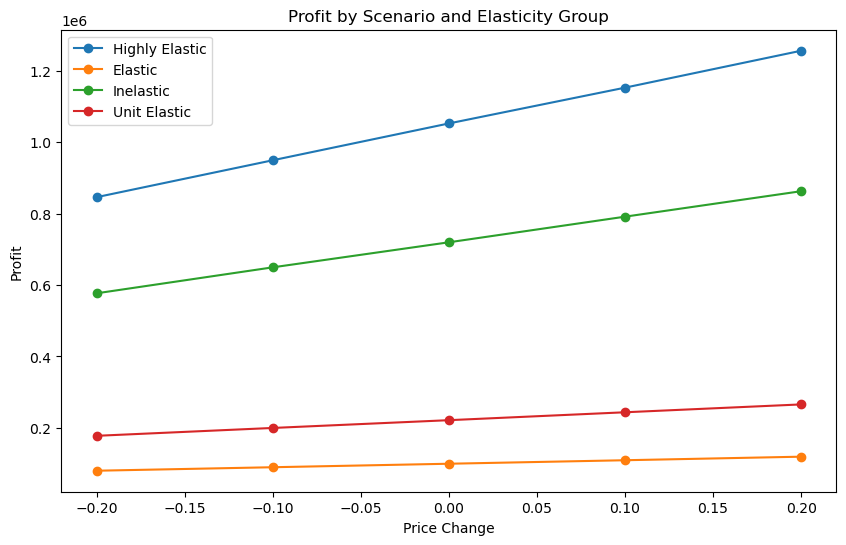

In [121]:
plt.figure(figsize=(10,6))

for group in group_profit_results[
    "ElasticityGroup"
].unique():

    subset = group_profit_results[
        group_profit_results[
            "ElasticityGroup"
        ] == group
    ]

    plt.plot(
        subset["Scenario"],
        subset["Profit"],
        marker="o",
        label=group
    )

plt.legend()

plt.title(
    "Profit by Scenario and Elasticity Group"
)

plt.xlabel(
    "Price Change"
)

plt.ylabel(
    "Profit"
)

plt.show()

In [122]:
product_elasticity = (
    monthly_product
    .groupby("StockCode", as_index=False)
    ["Elasticity"]
    .mean()
)

product_elasticity.head()

,StockCode,Elasticity
0,10002,-9.486710
1,10125,-2.279018
2,10133,-4.714887
3,10135,5.917952
4,11001,-7.525243


In [123]:
most_elastic = (
    product_elasticity
    .sort_values(
        "Elasticity"
    )
    .head(10)
)

most_elastic

,StockCode,Elasticity
2346,72816,-165.839050
560,21635,-153.156142
2638,84989a,-126.300000
737,21926,-123.898608
2942,90183A,-118.000000
2973,90202B,-118.000000
2982,90210A,-118.000000
2856,90051,-117.833333
148,20785,-108.500000
27,16161U,-103.516667


In [124]:
least_elastic = (
    product_elasticity
    .sort_values(
        "Elasticity",
        ascending=False
    )
    .head(10)
)

least_elastic

,StockCode,Elasticity
655,21801,86.190358
2889,90122A,77.308824
2922,90161C,67.901585
2927,90165B,66.933333
2978,90206C,65.389610
2887,90120C,61.041477
2939,90179A,60.358974
2825,90013A,57.990625
2053,23454,57.903024
2883,90114,57.208333


In [125]:
product_names = (
    retail_clean[
        ["StockCode", "Description"]
    ]
    .drop_duplicates()
)

In [126]:
most_elastic = most_elastic.merge(
    product_names,
    on="StockCode",
    how="left"
)

most_elastic

,StockCode,Elasticity,Description
0,72816,-165.839050,SET/3 CHRISTMAS DECOUPAGE CANDLES
1,21635,-153.156142,MADRAS NOTEBOOK LARGE
2,84989a,-126.300000,75 GREEN FAIRY CAKE CASES
3,21926,-123.898608,RED/CREAM STRIPE CUSHION COVER
4,90183A,-118.000000,AMBER DROP EARRINGS W LONG BEADS
5,90202B,-118.000000,WHITE ENAMEL FLOWER HAIR TIE
6,90210A,-118.000000,GREY ACRYLIC FACETED BANGLE
7,90051,-117.833333,CRACKED GLAZE NECKLACE RED
8,20785,-108.500000,FUSCHIA RETRO BAR STOOL
9,16161U,-103.516667,WRAP SUKI AND FRIENDS


In [127]:
least_elastic = least_elastic.merge(
    product_names,
    on="StockCode",
    how="left"
)

least_elastic

,StockCode,Elasticity,Description
0,21801,86.190358,CHRISTMAS TREE DECORATION WITH BELL
1,90122A,77.308824,PINK CRYSTAL+GLASS BRACELET
2,90161C,67.901585,ANT COPPER LIME BOUDICCA BRACELET
3,90165B,66.933333,WHITE ROSEBUD PEARL EARRINGS
4,90206C,65.389610,CRYSTAL DIAMANTE STAR BROOCH
5,90120C,61.041477,GREEN MURANO TWIST BRACELET
6,90179A,60.358974,AMBER FINE BEAD NECKLACE W TASSEL
7,90013A,57.990625,MIDNIGHT BLUE VINTAGE EARRINGS
8,23454,57.903024,SET OF 3 MINI HANGING PORTRAITS
9,23454,57.903024,THREE MINI HANGING FRAMES


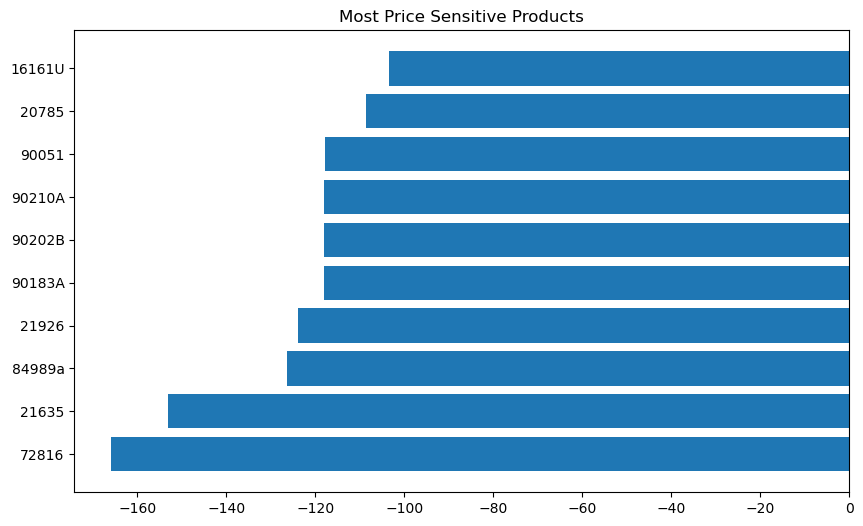

In [128]:
plt.figure(figsize=(10,6))

top10 = most_elastic.head(10)

plt.barh(
    top10["StockCode"].astype(str),
    top10["Elasticity"]
)

plt.title(
    "Most Price Sensitive Products"
)

plt.show()

In [129]:
model_data = monthly_product.copy()

In [130]:
model_data = pd.get_dummies(
    model_data,
    columns=["ElasticityGroup"],
    drop_first=True
)

In [131]:
model_data.columns

Index(['StockCode', 'YearMonth', 'Quantity', 'UnitPrice', 'Sales', 'CPI',
       'RealPrice', 'PriceChangeRate', 'RollingDemand3M',
       'PreviousMonthDemand', 'DemandChangeRate', 'Elasticity',
       'ElasticityGroup_Elastic', 'ElasticityGroup_Unit Elastic',
       'ElasticityGroup_Inelastic'],
      dtype='object')

In [132]:
features_v2 = [
    "UnitPrice",
    "CPI",
    "RealPrice",
    "PriceChangeRate",
    "RollingDemand3M",
    "PreviousMonthDemand",
    "Elasticity",
    "ElasticityGroup_Elastic",
    "ElasticityGroup_Unit Elastic",
    "ElasticityGroup_Inelastic"
]

In [133]:
X2 = model_data[features_v2]

y2 = model_data["Quantity"]

In [134]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

In [135]:
xgb_model_v2 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

In [136]:
xgb_model_v2.fit(
    X2_train,
    y2_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [137]:
pred_v2 = xgb_model_v2.predict(
    X2_test
)

In [138]:
r2_v2 = r2_score(
    y2_test,
    pred_v2
)

rmse_v2 = mean_squared_error(
    y2_test,
    pred_v2
) ** 0.5

mae_v2 = mean_absolute_error(
    y2_test,
    pred_v2
)

print("MAE:", mae_v2)
print("RMSE:", rmse_v2)
print("R²:", r2_v2)

MAE: 34.92275619506836
RMSE: 180.53133384540203
R²: 0.7615160346031189


In [139]:
importance_v2 = pd.DataFrame({
    "Feature": features_v2,
    "Importance": xgb_model_v2.feature_importances_
})

importance_v2.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,RollingDemand3M,0.727661
1,CPI,0.086951
6,Elasticity,0.057855
3,PriceChangeRate,0.038164
5,PreviousMonthDemand,0.032344
2,RealPrice,0.028415
8,ElasticityGroup_Unit Elastic,0.013906
0,UnitPrice,0.008329
7,ElasticityGroup_Elastic,0.006375
9,ElasticityGroup_Inelastic,0.000000


In [140]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "XGBoost + Elasticity Segments"
    ],
    "R2": [
        0.7147,
        0.7481,
        0.7615
    ],
    "RMSE": [
        197.45,
        185.54,
        180.53
    ],
    "MAE": [
        36.81,
        35.73,
        34.92
    ]
})

comparison

,Model,R2,RMSE,MAE
0,Random Forest,0.7147,197.45,36.81
1,XGBoost,0.7481,185.54,35.73
2,XGBoost + Elasticity Segments,0.7615,180.53,34.92


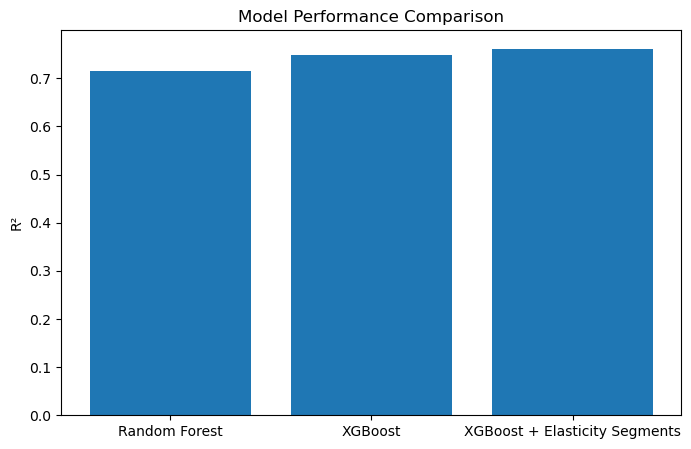

In [141]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("R²")

plt.show()

In [142]:
from sklearn.model_selection import RandomizedSearchCV

In [143]:
param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

In [144]:
random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [145]:
random_search.fit(
    X2_train,
    y2_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [146]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 300,
 'max_depth': 7,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [147]:
best_xgb = random_search.best_estimator_

In [148]:
best_pred = best_xgb.predict(
    X2_test
)

best_r2 = r2_score(
    y2_test,
    best_pred
)

best_rmse = mean_squared_error(
    y2_test,
    best_pred
) ** 0.5

best_mae = mean_absolute_error(
    y2_test,
    best_pred
)

print("MAE:", best_mae)
print("RMSE:", best_rmse)
print("R²:", best_r2)

MAE: 32.034549713134766
RMSE: 172.23580311596078
R²: 0.7829294204711914


In [149]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 300,
 'max_depth': 7,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [150]:
best_r2

0.7829294204711914

In [151]:
profit_results

,Scenario,TotalProfit,Recommendation
0,-0.2,1.681061e+06,Strong Discount
1,-0.1,1.888848e+06,Discount
2,0.0,2.093641e+06,Current Price
3,0.1,2.297515e+06,Price Increase
4,0.2,2.504188e+06,Strong Price Increase


In [152]:
best_profit = profit_results[
    "TotalProfit"
].max()

worst_profit = profit_results[
    "TotalProfit"
].min()

print(best_profit)
print(worst_profit)

2504188.096369519
1681060.519538174


In [153]:
alphas = [0.3, 0.5, 0.7]

hurwicz_results = []

for alpha in alphas:

    score = (
        alpha * best_profit
        +
        (1 - alpha) * worst_profit
    )

    hurwicz_results.append({
        "Alpha": alpha,
        "HurwiczScore": score
    })

hurwicz_df = pd.DataFrame(
    hurwicz_results
)

hurwicz_df

,Alpha,HurwiczScore
0,0.3,1.927999e+06
1,0.5,2.092624e+06
2,0.7,2.257250e+06


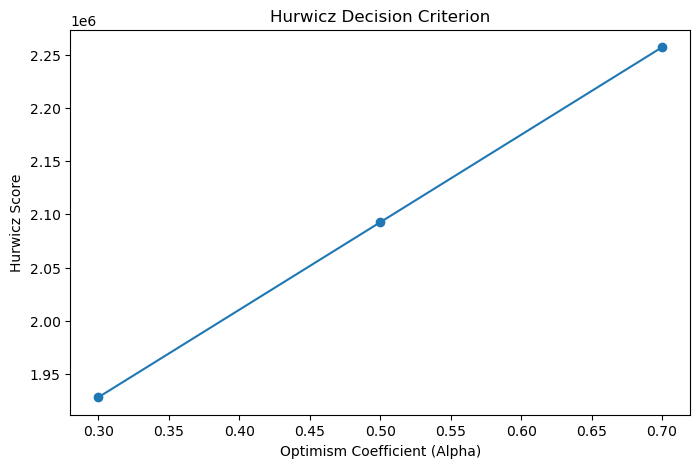

In [154]:
plt.figure(figsize=(8,5))

plt.plot(
    hurwicz_df["Alpha"],
    hurwicz_df["HurwiczScore"],
    marker="o"
)

plt.title(
    "Hurwicz Decision Criterion"
)

plt.xlabel(
    "Optimism Coefficient (Alpha)"
)

plt.ylabel(
    "Hurwicz Score"
)

plt.show()

In [155]:
hurwicz_data = []

In [156]:
hurwicz_data = []

for scenario in [-0.20, -0.10, 0.00, 0.10, 0.20]:

    temp = model_data.copy()

    temp["UnitPrice"] = (
        temp["UnitPrice"]
        * (1 + scenario)
    )

    temp["RealPrice"] = (
        temp["UnitPrice"]
        / temp["CPI"]
    )

    predicted_demand = best_xgb.predict(
        temp[X2.columns]
    )

    temp["Revenue"] = (
        temp["UnitPrice"]
        * predicted_demand
    )

    temp["Cost"] = (
        temp["UnitPrice"]
        * 0.70
        * predicted_demand
    )

    temp["Profit"] = (
        temp["Revenue"]
        - temp["Cost"]
    )

    hurwicz_data.append({
        "Scenario": scenario,
        "BestProfit": temp["Profit"].quantile(0.95),
        "WorstProfit": temp["Profit"].quantile(0.05),
        "AverageProfit": temp["Profit"].mean()
    })

In [157]:
hurwicz_table = pd.DataFrame(hurwicz_data)

hurwicz_table

,Scenario,BestProfit,WorstProfit,AverageProfit
0,-0.2,346.180575,0.517320,88.089431
1,-0.1,389.176928,0.678591,98.972247
2,0.0,430.814350,0.713201,109.627908
3,0.1,473.799932,0.861338,120.276743
4,0.2,516.864368,0.998618,131.072475


In [158]:
alpha = 0.6

hurwicz_table["HurwiczScore"] = (
    alpha * hurwicz_table["BestProfit"]
    +
    (1 - alpha) * hurwicz_table["WorstProfit"]
)

In [159]:
hurwicz_table.sort_values(
    "HurwiczScore",
    ascending=False
)

,Scenario,BestProfit,WorstProfit,AverageProfit,HurwiczScore
4,0.2,516.864368,0.998618,131.072475,310.518068
3,0.1,473.799932,0.861338,120.276743,284.624495
2,0.0,430.814350,0.713201,109.627908,258.773891
1,-0.1,389.176928,0.678591,98.972247,233.777593
0,-0.2,346.180575,0.517320,88.089431,207.915273


In [160]:
FINAL_MODEL = best_xgb

FINAL_FEATURES = features_v2

FINAL_DATA = model_data

In [161]:
print(FINAL_MODEL)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [162]:
print(FINAL_FEATURES)

['UnitPrice', 'CPI', 'RealPrice', 'PriceChangeRate', 'RollingDemand3M', 'PreviousMonthDemand', 'Elasticity', 'ElasticityGroup_Elastic', 'ElasticityGroup_Unit Elastic', 'ElasticityGroup_Inelastic']


In [163]:
print(FINAL_DATA.shape)

(19081, 15)


In [164]:
sample = FINAL_DATA[
    FINAL_FEATURES
].head()

FINAL_MODEL.predict(sample)

array([71.30143 , 48.257698, 74.57727 , 84.28805 , 69.87301 ],
      dtype=float32)

In [165]:
FINAL_DATA[
    FINAL_FEATURES
].isnull().sum()

UnitPrice                       0
CPI                             0
RealPrice                       0
PriceChangeRate                 0
RollingDemand3M                 0
PreviousMonthDemand             0
Elasticity                      0
ElasticityGroup_Elastic         0
ElasticityGroup_Unit Elastic    0
ElasticityGroup_Inelastic       0
dtype: int64

# Sonuç ve Yönetim Önerileri

- Online Retail ve UK CPI veri setleri başarıyla entegre edilmiştir.
- Talep esnekliği hesaplanmış ve ürün segmentleri oluşturulmuştur.
- Hyperparameter Optimization uygulanmış XGBoost modeli en başarılı model olarak belirlenmiştir (R² = 0.783).
- SHAP analizi model kararlarının yorumlanmasını sağlamıştır.
- Fiyat senaryoları altında gerçekleştirilen kâr optimizasyonu sonucunda %20 fiyat artışı senaryosu en yüksek beklenen kârı sağlamıştır.
- Hurwicz Karar Kriteri kullanılarak farklı yönetsel risk tercihleri değerlendirilmiştir.
- Sonuçlar, veri odaklı dinamik fiyatlama stratejilerinin enflasyonist ortamlarda işletme kârlılığını artırabileceğini göstermektedir.